# Phase 1 & 2: Real Estate Business Problem & Synthetic Data Generation

## 1. Project Background & Business Problem
Real-estate companies frequently launch residential plot schemes and advertise them through newspapers, digital media, and portals.
Before launching a new scheme, developers and marketing teams need to understand:
1. **Customer Purchase Intent**: Which prospective leads are likely to respond and purchase a residential plot?
2. **Scheme Demand**: How many inquiries, site visits, and bookings will a proposed scheme generate?

### Empirical Calibration
To ensure the synthetic data closely reflects Indian real estate dynamics, the distributions are calibrated with:
- **Magicbricks Housing Sentiment Index (HSI 2024)**: Age distributions, budget-to-income multiplier (3-5x annual income), home loan reliance (82%).
- **ANAROCK Consumer Sentiment & 2025 Reports**: End-use vs investment breakdown (58% vs 42%), city-wise preferences, and suburban corridor growth.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

clean_path = os.path.join("..", "data", "real_estate_clean.csv")
messy_path = os.path.join("..", "data", "real_estate_raw_messy.csv")
scheme_path = os.path.join("..", "data", "historical_scheme_data.csv")

df_clean = pd.read_csv(clean_path)
df_messy = pd.read_csv(messy_path)
df_scheme = pd.read_csv(scheme_path)

print(f"Clean Customer Dataset: {df_clean.shape}")
print(f"Messy Customer Dataset: {df_messy.shape}")
print(f"Historical Scheme Dataset: {df_scheme.shape}")


Clean Customer Dataset: (12000, 26)
Messy Customer Dataset: (12180, 26)
Historical Scheme Dataset: (800, 16)


## 2. Dataset Schema & First Look (Clean Dataset)

In [2]:
df_clean.head(5)

,Customer_ID,Age,Gender,Occupation,City,Monthly_Income,Annual_Income,Family_Size,Current_Housing_Status,Plot_Budget,...,Lead_Source,Enquiry_Date,Previous_Enquiry,Site_Visit,Negotiation_Done,Booking_Done,Purchase_Probability,Purchase_Intent,Purchased,Purchase_Value
0,CUST_10001,23,Female,IT & Software,Bengaluru,31700,380400,3,Rented,2000000,...,Print / Newspaper Ad,2024-02-28,No,No,No,No,0.1402,Low,No,0
1,CUST_10002,31,Male,Government & PSU,Mumbai,98700,1184400,4,Owned Flat/House,5080000,...,Google & Social Media Ads,2024-08-18,No,No,No,No,0.1568,Low,No,0
2,CUST_10003,39,Female,BFSI & Banking,Delhi,144200,1730400,5,Living with Parents,5040000,...,Magicbricks / Real Estate Portal,2024-05-08,No,Yes,No,No,0.2337,Low,No,0
3,CUST_10004,67,Female,Healthcare & Doctor,Bengaluru,808100,9697200,3,Owned Flat/House,42740000,...,Channel Partner / Broker,2024-08-27,Yes,Yes,Yes,Yes,0.9900,High,Yes,41880000
4,CUST_10005,42,Male,Retail & Commerce,Delhi,53900,646800,5,Rented,2890000,...,Magicbricks / Real Estate Portal,2024-05-19,Yes,No,No,No,0.1047,Low,No,0


In [3]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Customer_ID                 12000 non-null  object 
 1   Age                         12000 non-null  int64  
 2   Gender                      12000 non-null  object 
 3   Occupation                  12000 non-null  object 
 4   City                        12000 non-null  object 
 5   Monthly_Income              12000 non-null  int64  
 6   Annual_Income               12000 non-null  int64  
 7   Family_Size                 12000 non-null  int64  
 8   Current_Housing_Status      12000 non-null  object 
 9   Plot_Budget                 12000 non-null  int64  
 10  Preferred_Plot_Size_SqFt    12000 non-null  int64  
 11  Preferred_Location          12000 non-null  object 
 12  Distance_to_City_Center_km  12000 non-null  float64
 13  Purpose                     120

## 3. Target Distribution Verification
We inspect the target variables: `Purchased` (Yes/No), `Purchase_Intent` (High/Medium/Low), and `Purchase_Probability`.


In [4]:
print("Purchased Breakdown (%):")
print(df_clean['Purchased'].value_counts(normalize=True).round(4) * 100)

print("\nPurchase Intent Breakdown (%):")
print(df_clean['Purchase_Intent'].value_counts(normalize=True).round(4) * 100)


Purchased Breakdown (%):
Purchased
No     58.46
Yes    41.54
Name: proportion, dtype: float64

Purchase Intent Breakdown (%):
Purchase_Intent
Low       55.09
High      29.58
Medium    15.33
Name: proportion, dtype: float64


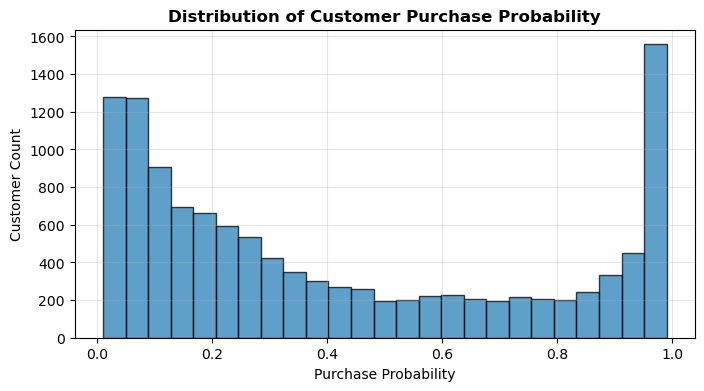

In [5]:
plt.figure(figsize=(8, 4))
df_clean['Purchase_Probability'].plot(kind='hist', bins=25, color='#2980b9', edgecolor='black', alpha=0.75)
plt.title("Distribution of Customer Purchase Probability", fontsize=12, fontweight='bold')
plt.xlabel("Purchase Probability")
plt.ylabel("Customer Count")
plt.grid(True, alpha=0.3)
plt.show()


## 4. Historical Residential Plot Scheme Data Preview

In [6]:
df_scheme.head(5)

,Scheme_ID,Location,Plot_Size_SqFt,Price_INR,Monthly_EMI_INR,Park,Clubhouse,Distance_from_Metro_km,Advertising_Budget_INR,Expected_Leads,Expected_Bookings,Estimated_Conversion_Pct,Demand_Level,Scheme_Success_Score,Target_Age_Group,Most_Likely_Buyers
0,SCH_0101,Delhi (Outer/Bawana),800,1320000,9200,Yes,No,3.9,1500000,3230,602,18.6,HIGH,79,25-38,First-time Buyers & Investors
1,SCH_0102,Gurugram (SPR/Sohna),1800,8270000,57400,Yes,Yes,16.2,1500000,2335,348,14.9,HIGH,79,40-60,Affluent Investors & Luxury Homes
2,SCH_0103,Kolkata (New Town/Rajarhat),1500,3030000,21000,Yes,No,5.5,750000,1267,227,17.9,MEDIUM,74,25-38,First-time Buyers & Investors
3,SCH_0104,Bengaluru (North),1000,6360000,44200,Yes,No,23.9,1000000,1015,99,9.8,LOW,41,32-48,Self-use (Villa) + Investment
4,SCH_0105,Greater Noida,2400,8150000,56600,No,No,23.4,1000000,1180,73,6.2,LOW,25,40-60,Affluent Investors & Luxury Homes
